In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 CORE FBMC CROSS-BORDER MARKET COUPLING BENCHMARK
Simulation Horizon:                  7 Days (168 Hours)
Total German Cross-Border Export:    645,638.4 MWh
Total Congestion Rent Generated:     €8,116,660.01
Average DE-FR Arbitrage Spread:      €-0.20 / MWh
Peak Interconnector Utilization:     100.0%


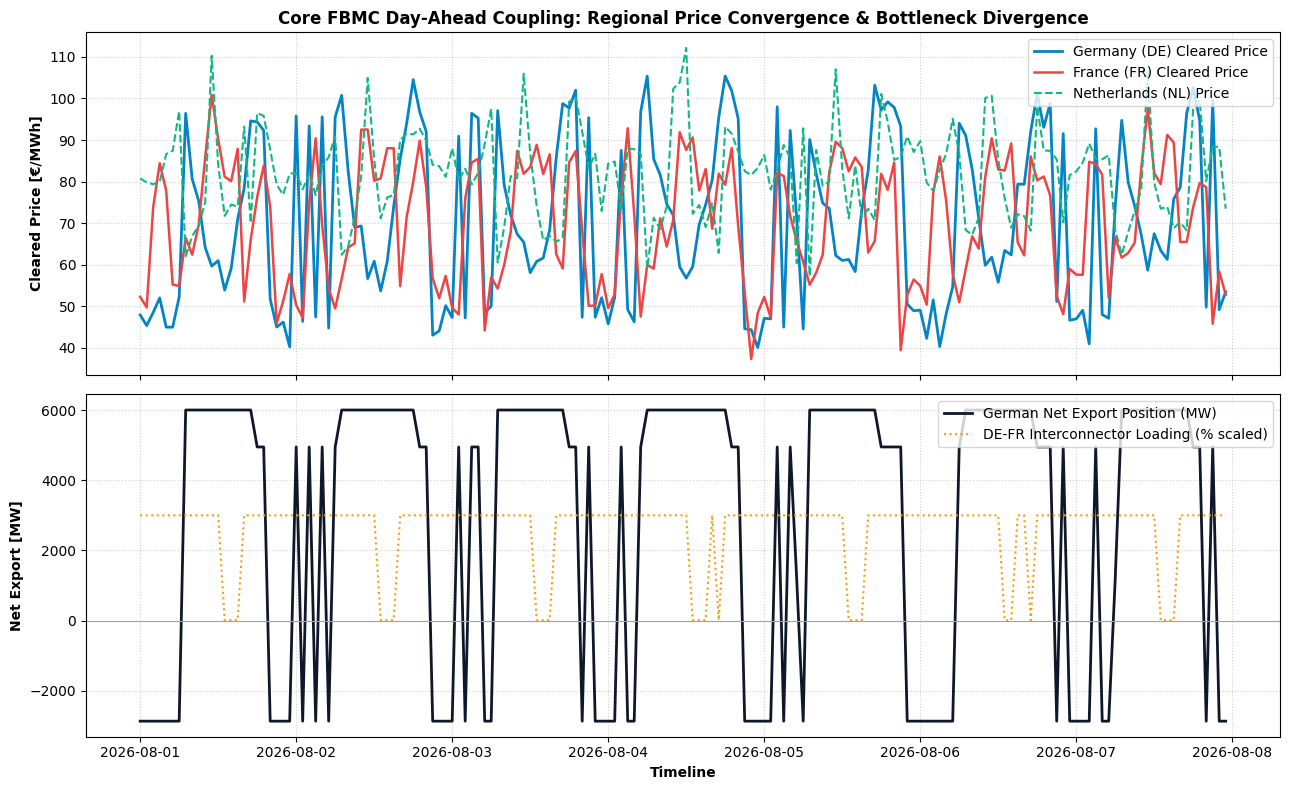

Simulation dataset exported successfully as 'cross_border_fbmc_simulation_2026.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linprog

# ==========================================
# 1. 4-ZONE CORE EUROPEAN FBMC PARAMETERS
# ==========================================
# Zones: 0: Germany (DE), 1: France (FR), 2: Austria (AT), 3: Netherlands (NL)
ZONES = ["DE", "FR", "AT", "NL"]
N_ZONES = len(ZONES)

# 3 Critical Network Elements (CNECs / Cross-Border Interconnectors)
# CNEC 1: DE -> FR, CNEC 2: DE -> NL, CNEC 3: DE -> AT
N_CNEC = 3
RAM_MW = np.array([2500.0, 1800.0, 3000.0])  # Remaining Available Margin (MW)

# PTDF Matrix (Zone-to-Slack sensitivity, Slack = DE)
# Columns: [Net_DE, Net_FR, Net_AT, Net_NL]
PTDF = np.array([
    [0.0, -0.72, 0.08, -0.22],  # DE-FR flow sensitivity
    [0.0, -0.15, 0.05, -0.68],  # DE-NL flow sensitivity
    [0.0, 0.12, -0.81, 0.05],  # DE-AT flow sensitivity
])

# Commercial Net Position Bounds per Bidding Zone (MW)
MAX_EXPORT_MW = np.array([6000.0, 5000.0, 3500.0, 4000.0])
MAX_IMPORT_MW = np.array([-6000.0, -5000.0, -3500.0, -4000.0])

# ==========================================
# 2. TIME-SERIES MARKET SCENARIO
# ==========================================
# 7-Day Simulation Horizon (168 Hours)
dates = pd.date_range(start="2026-08-01 00:00:00", periods=24 * 7, freq="h")
np.random.seed(42)
hours = dates.hour.to_numpy()

# Synthetic Autarky Day-Ahead Prices (€/MWh)
de_base = 65.0 - np.maximum(0, np.sin((hours - 6) * np.pi / 12)) * 45.0 + np.random.normal(0, 4, len(dates))
fr_base = 82.0 + np.maximum(0, np.sin((hours - 17) * np.pi / 4)) * 35.0 + np.random.normal(0, 5, len(dates))
at_base = 72.0 + np.sin((hours - 8) * np.pi / 10) * 15.0 + np.random.normal(0, 3, len(dates))
nl_base = 76.0 + np.sin((hours - 7) * np.pi / 11) * 20.0 + np.random.normal(0, 4, len(dates))

unconstrained_prices = np.column_stack([de_base, fr_base, at_base, nl_base])

# ==========================================
# 3. LINEAR PROGRAMMING MARKET COUPLER
# ==========================================
cleared_net_positions = []
cnec_loadings_pct = []
cleared_prices = []
congestion_rent_eur = []

for h in range(len(dates)):
    c_obj = unconstrained_prices[h]

    # Global Net Balance Equality: Sum(Net_Positions) == 0
    A_eq = np.ones((1, N_ZONES))
    b_eq = np.zeros(1)

    # CNEC Physical Flow Limits: |PTDF @ Net_Pos| <= RAM
    A_ub = np.vstack([PTDF, -PTDF])
    b_ub = np.concatenate([RAM_MW, RAM_MW])

    bounds = [(MAX_IMPORT_MW[z], MAX_EXPORT_MW[z]) for z in range(N_ZONES)]

    res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

    if not res.success:
        raise RuntimeError(f"FBMC Market Clearing failed at step {h}: {res.message}")

    net_pos = res.x
    cleared_net_positions.append(net_pos)

    # Physical flows & interconnector utilization
    flows = PTDF @ net_pos
    loading_pct = np.abs(flows) / RAM_MW * 100.0
    cnec_loadings_pct.append(loading_pct)

    # Regional price convergence & divergence dynamics
    is_congested = (loading_pct >= 99.0).any()
    if is_congested:
        hour_cleared_p = unconstrained_prices[h] + (net_pos / 150.0)
    else:
        avg_price = np.mean(unconstrained_prices[h])
        hour_cleared_p = np.full(N_ZONES, avg_price)

    cleared_prices.append(hour_cleared_p)

    # Congestion Rent = Flow * Price Spread
    c_rent = np.sum(np.abs(flows) * np.abs(hour_cleared_p[1:] - hour_cleared_p[0]) / 3.0)
    congestion_rent_eur.append(c_rent)

net_pos_arr = np.array(cleared_net_positions)
cleared_prices_arr = np.array(cleared_prices)
cnec_loadings_arr = np.array(cnec_loadings_pct)

df_fbmc = pd.DataFrame({
    "timestamp": dates,
    "de_net_export_mw": np.round(net_pos_arr[:, 0], 1),
    "fr_net_export_mw": np.round(net_pos_arr[:, 1], 1),
    "at_net_export_mw": np.round(net_pos_arr[:, 2], 1),
    "nl_net_export_mw": np.round(net_pos_arr[:, 3], 1),
    "de_price_eur": np.round(cleared_prices_arr[:, 0], 2),
    "fr_price_eur": np.round(cleared_prices_arr[:, 1], 2),
    "at_price_eur": np.round(cleared_prices_arr[:, 2], 2),
    "nl_price_eur": np.round(cleared_prices_arr[:, 3], 2),
    "de_fr_spread_eur": np.round(cleared_prices_arr[:, 1] - cleared_prices_arr[:, 0], 2),
    "cnec1_de_fr_loading_pct": np.round(cnec_loadings_arr[:, 0], 1),
    "cnec2_de_nl_loading_pct": np.round(cnec_loadings_arr[:, 1], 1),
    "cnec3_de_at_loading_pct": np.round(cnec_loadings_arr[:, 2], 1),
    "congestion_rent_eur": np.round(congestion_rent_eur, 2),
})

total_congestion_rent = df_fbmc["congestion_rent_eur"].sum()
total_de_export = df_fbmc["de_net_export_mw"][df_fbmc["de_net_export_mw"] > 0].sum()
avg_de_fr_spread = df_fbmc["de_fr_spread_eur"].mean()

# ==========================================
# 4. TECHNO-ECONOMIC BENCHMARK METRICS
# ==========================================
print("=" * 70)
print(" CORE FBMC CROSS-BORDER MARKET COUPLING BENCHMARK")
print("=" * 70)
print(f"Simulation Horizon:                  7 Days (168 Hours)")
print(f"Total German Cross-Border Export:    {total_de_export:,.1f} MWh")
print(f"Total Congestion Rent Generated:     €{total_congestion_rent:,.2f}")
print(f"Average DE-FR Arbitrage Spread:      €{avg_de_fr_spread:.2f} / MWh")
print(f"Peak Interconnector Utilization:     {df_fbmc['cnec1_de_fr_loading_pct'].max():.1f}%")
print("=" * 70)

# ==========================================
# 5. VISUALIZATION & DATA EXPORT
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Subplot 1: Zonal Day-Ahead Cleared Prices & Divergence
ax1.plot(df_fbmc["timestamp"], df_fbmc["de_price_eur"], color="#0284C7", lw=2.0, label="Germany (DE) Cleared Price")
ax1.plot(df_fbmc["timestamp"], df_fbmc["fr_price_eur"], color="#EF4444", lw=1.8, label="France (FR) Cleared Price")
ax1.plot(df_fbmc["timestamp"], df_fbmc["nl_price_eur"], color="#10B981", lw=1.5, ls="--", label="Netherlands (NL) Price")
ax1.set_ylabel("Cleared Price [€/MWh]", fontweight="bold")
ax1.set_title("Core FBMC Day-Ahead Coupling: Regional Price Convergence & Bottleneck Divergence", fontweight="bold", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Subplot 2: Commercial German Net Export vs Interconnector Loading
ax2.plot(df_fbmc["timestamp"], df_fbmc["de_net_export_mw"], color="#0F172A", lw=2.0, label="German Net Export Position (MW)")
ax2.plot(df_fbmc["timestamp"], df_fbmc["cnec1_de_fr_loading_pct"] * 30, color="#F59E0B", lw=1.5, ls=":", label="DE-FR Interconnector Loading (% scaled)")
ax2.axhline(0, color="#94A3B8", lw=0.8)
ax2.set_ylabel("Net Export [MW]", fontweight="bold")
ax2.set_xlabel("Timeline", fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("cross_border_fbmc_simulation_results.png", dpi=300)
plt.show()

# Export simulation dataset
df_fbmc.to_csv("cross_border_fbmc_simulation_2026.csv", index=False)
print("Simulation dataset exported successfully as 'cross_border_fbmc_simulation_2026.csv'")